# Лабораторная номер 1 по анализу данных на Python

## Импорты 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

## Загружаем данные

In [6]:
# Загружаем данные с помощью pandas метода read_csv
df = pd.read_csv("Econom_Cities_data.csv", sep=";")

# Смотрим на данные 
df.head(5)

,City,Work,Price,Salary
0,Amsterdam,1714,"65,6",49
1,Athens,1792,"53,8","30,4"
2,Bogota,2152,"37,9","11,5"
3,Bombay,2052,"30,3","5,3"
4,Brussels,1708,"73,8","50,5"


In [7]:
# типы данных для каждого столбца
# только Work имеет числовой тип int64
df.dtypes

City      object
Work       int64
Price     object
Salary    object
dtype: object

In [8]:
assert len(df["City"].unique()) == len(df) # Все города уникальны

Так как города уникальны, можно установить колонку City в качестве индекса нашего pandas датафрейма.

In [10]:
# Устанавливаем индексом колонку "City"
df = df.set_index("City")

## Предобработка данных

Преобразуем колонки Price и Salary, чтобы их тип был float64.

In [13]:
df["Price"] = (df["Price"].apply(lambda x: x.replace(",", "."))).astype(float)
df["Salary"] = (df["Salary"].apply(lambda x: x.replace(",", "."))).astype(float)

Так как наши признаки имеют разный масштаб (например, значения признака Work по наблюдениям сильно больше значений признака Salary), нам надо стандартизировать их.

Для этого мы импортируем StandardScaler из sklearn и стандартизуем данные. 

In [15]:
standard_scaler = StandardScaler()

# Записываем стандартизованные данные тоже в pandas.DataFrame с тем же индексом и теми же названиями колонок
df_scaled = pd.DataFrame(standard_scaler.fit_transform(df.values), index=df.index, columns=df.columns)

## Кластерный анализ

### Попробуем найти шаровые кластеры

In [18]:
# Создаем копию стандартизованных данных
df_ward = df_scaled.copy(deep=True)

# Проводим иерархический кластерный анализ методом Уорда с метрикой = расстояние Евклида
# используя функцию linkage из библиотеки SciPy
link_ward = linkage(df_ward, "ward", "euclidean")

Рисуем дендрограмму кластеризации

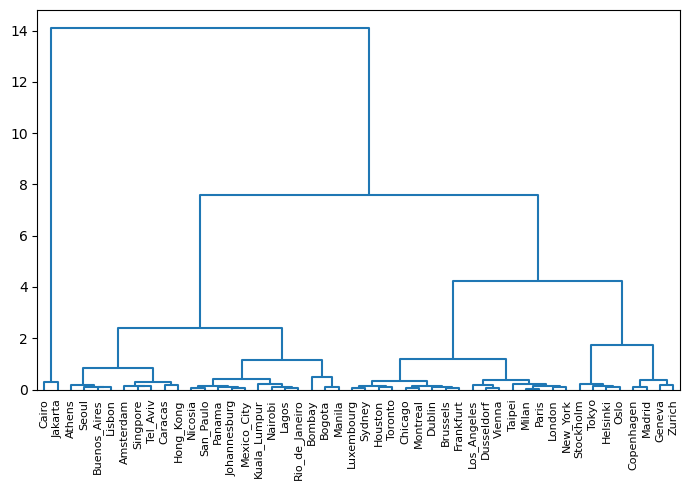

In [20]:
fig = plt.figure(figsize=(7, 5))

dn = dendrogram(link_ward, 
                labels=df_ward.index.tolist(),
                color_threshold=-1)

plt.tight_layout()
plt.show()

Может быть Каир (Cairo) и Джакарта (Jakarta) являются выбросами - посмотрим оригинальный датафрейм.

In [22]:
df.loc[["Cairo", "Jakarta"]]

,Work,Price,Salary
City,,,
Cairo,-9999,37.1,-9999.0
Jakarta,-9999,43.6,-9999.0


Очевидно, что города Cairo и Jakarta действительно являются выбросами. Удалим из df эти города. И заново отскалируем (потому что выборочное среднее и выборочная дисперсия изменятся) и получим df_scaled без Каира и Джакарты и с правильно стандартизированными признаками.

In [24]:
# Убираем из данных Каир и Джакарту
df = df.loc[~df_scaled.index.isin(["Cairo", "Jakarta"])]

# Заново стандартизируем данные
standard_scaler = StandardScaler()

# Записываем стандартизованные данные тоже в pandas.DataFrame с тем же индексом и теми же названиями колонок
df_scaled = pd.DataFrame(standard_scaler.fit_transform(df.values), index=df.index, columns=df.columns)

df_ward = df_scaled.copy(deep=True)

Построим еще раз дендрограмму кластеризации

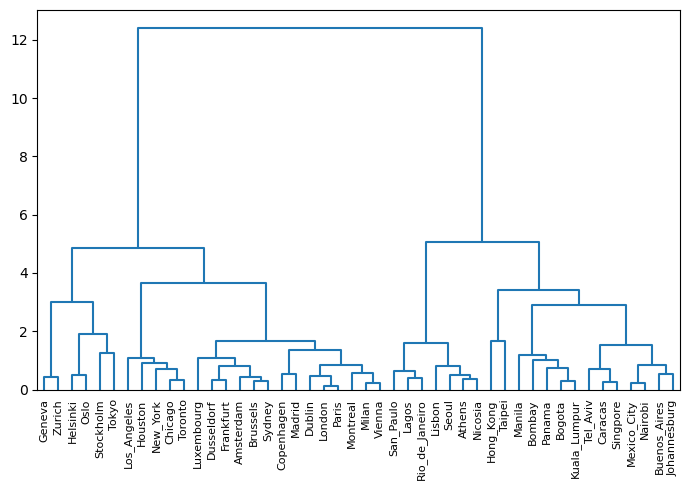

In [26]:
link_ward_update = linkage(df_ward, "ward", "euclidean")

fig = plt.figure(figsize=(7, 5))

dn = dendrogram(link_ward_update, 
                labels=df_ward.index.tolist(),
                color_threshold=-1)

plt.tight_layout()
plt.show()

Из этого графика всё же не очень понятно, какое у нас оптимальное для интерпретации число кластеров.

Для этого нарисуем график «каменистая осыпь» (зависимость расстояния от объединяемых кластеров на каждом шаге от номера шага).

Рисуем график каменистая осыпь

Text(0, 0.5, 'Расстояние')

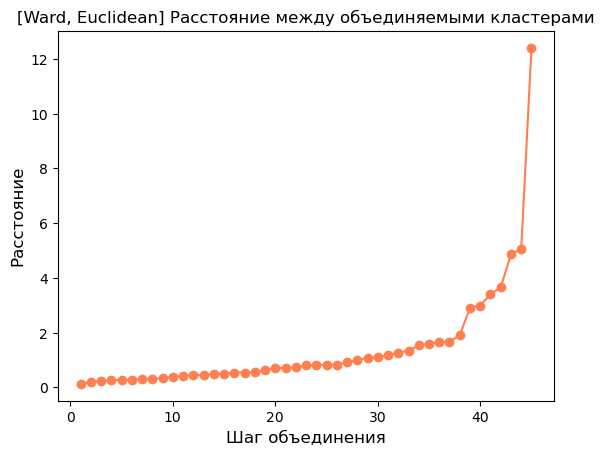

In [29]:
# Расстояния между кластерами на момент объединения
dist_update = link_ward_update[:, 2]
# dist_rev = dist[::-1]
idxs = range(1, len(dist_update) + 1)  # Шаги

# График каменистая осыпь 
plt.plot(idxs, dist_update, marker='o', color="coral")
plt.title(f'[Ward, Euclidean] Расстояние между объединяемыми кластерами', fontsize=12)
plt.xlabel('Шаг объединения', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)

Исходя из графика каменистая осыпь оставим число кластеров равным 4, мы их получим, если примем остановку объединений кластеров по расстоянию = 4.

In [31]:
# Оставляем 4 кластера
df["cluster"] = fcluster(link_ward_update, 4, criterion="distance")

In [32]:
# df_ward['cluster'] = fcluster(link_ward_update, 4, criterion='maxclust')

Найдем средние значения наших признаков в каждом кластере

In [34]:
#  Средние значения  в каждом кластере из 4
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
1,1780.500000,108.550000,71.300000
2,1792.000000,77.526316,55.157895
3,1798.857143,50.942857,19.214286
4,2082.357143,53.121429,14.914286


#### Анализ кластеров

**Кластер 1**

В кластере 1 находятся города, в которых самое низкое количество рабочих часов, самые высокие цены на товары и услуги, а также самые высокие средние зарплаты после налогов — это города из 3 скандинавских стран, Токио и 2 самых главных города Швейцарии — Цюрих и Женева. То есть в первом кластере находятся самые дорогие города из стран первого мира, довольно социальные (с небольшим количеством рабочих часов), не сугубо капиталистические.

In [37]:
df[df["cluster"] == 1]

,Work,Price,Salary,cluster
City,,,,
Geneva,1880,95.9,90.3,1
Helsinki,1667,113.6,66.6,1
Oslo,1583,115.5,63.7,1
Stockholm,1805,111.3,39.2,1
Tokyo,1880,115.0,68.0,1
Zurich,1868,100.0,100.0,1


**Кластер 2**

В кластере 2 находятся города, в которых немного большее количество рабочих часов, чем в городах из первого кластера, но при этом также сильно ниже цены на товары и услуги, а также сильно ниже средние зарплаты — это города из развитых стран, не настолько дорогие, как города из первого кластера.

In [39]:
df[df["cluster"] == 2]

,Work,Price,Salary,cluster
City,,,,
Amsterdam,1714,65.6,49.0,2
Brussels,1708,73.8,50.5,2
Chicago,1924,73.9,61.9,2
Copenhagen,1717,91.3,62.9,2
Dublin,1759,76.0,41.4,2
Dusseldorf,1693,78.5,60.2,2
Frankfurt,1650,74.5,60.4,2
Houston,1978,71.9,46.3,2
London,1737,84.2,46.2,2


**Кластер 3**

В кластере 3 находятся города, в которых немного большее количество часов, чем в городах из второго кластера. Однако ниже зарплаты и цены на товары и услуги, при этом падение в средней зарплате по сравнению со 2 кластером сильнее, чем падение цен на товары и услуги по сравнению с тем же 2 кластером. В основном в этом кластере находятся города из развивающихся стран и не самых богатых стран Европы. В этих городах работают больше, чем в городах из первого и второго кластера, цены ниже, зарплаты тоже ниже — но падение в средней зарплате сильнее, чем в ценах на товары и услуги.

In [41]:
df[df["cluster"] == 3]

,Work,Price,Salary,cluster
City,,,,
Athens,1792,53.8,30.4,3
Lagos,1786,45.2,2.7,3
Lisbon,1742,56.2,18.8,3
Nicosia,1825,47.9,28.3,3
Rio_de_Janeiro,1749,46.3,10.5,3
San_Paulo,1856,48.9,11.1,3
Seoul,1842,58.3,32.7,3


**Кластер 4**

В кластере 4 находятся города, в которых работают сильно больше, чем в городах из остальных кластеров, цены даже немного выше, чем в 3 кластере, а средние зарплаты самые низкие среди всех кластеров. В этом кластере много городов из самых бедных стран Латинской Америки (например, Bogota — Колумбия, Caracas — Венесуэла, Panama — Панама), из бедных стран Африки (например, Nairobi — Кения, Johannesburg — ЮАР), из бедных стран Азии (например, Kuala Lumpur — Малайзия, Manila — Филиппины, Bombay — Индия). В этом кластере нет городов из Европы.

In [43]:
df[df["cluster"] == 4]

,Work,Price,Salary,cluster
City,,,,
Bogota,2152,37.9,11.5,4
Bombay,2052,30.3,5.3,4
Buenos_Aires,1971,56.1,12.5,4
Caracas,2041,61.0,10.9,4
Hong_Kong,2375,63.8,27.8,4
Johannesburg,1945,51.1,24.0,4
Kuala_Lumpur,2167,43.5,9.9,4
Manila,2268,40.0,4.0,4
Mexico_City,1944,49.8,5.7,4


#### Может быть мы ошиблись и кластеров больше (допустим, 5)?

Если мы примем решение о том, что у нас 5 кластеров, то у нас будет 2 очень похожих кластера (с маленьким расстоянием между ними), которые мы не объединим. Конечно, из графика «каменистая осыпь» также видно, что у нас и в случае 4 кластеров будет 2 довольно близких кластера, которые мы не объединяем — так что количество выбранных кластеров зависит от индивидуального решения аналитика.

In [46]:
# Оставляем 5 кластеров
df["cluster"] = fcluster(link_ward_update, 5, criterion="maxclust")

In [47]:
#  Средние значения  в каждом кластере из 5
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
1,1780.500000,108.550000,71.300000
2,1960.000000,75.820000,59.480000
3,1732.000000,78.135714,53.614286
4,1798.857143,50.942857,19.214286
5,2082.357143,53.121429,14.914286


Кластер 2 из случая, когда у нас было 4 кластера (города, в которых немного большее количество рабочих часов, чем в городах из первого кластера, но при этом также сильно ниже цены на товары и услуги, а также сильно ниже средние зарплаты — это города из развитых стран, не настолько дорогие, как города из первого кластера), разделился на два других кластера: на города США + Торонто из Канады, в которых люди работают очень много (выше только в городах из 4 кластера) — Чикаго, Хьюстон, Лос-Анджелес и Нью-Йорк, и на другие города — в основном из Европы.

Смотрим на кластер 2 из получившихся 5.

In [50]:
df[df["cluster"] == 2]

,Work,Price,Salary,cluster
City,,,,
Chicago,1924,73.9,61.9,2
Houston,1978,71.9,46.3,2
Los_Angeles,2068,79.8,65.2,2
New_York,1942,83.3,65.8,2
Toronto,1888,70.2,58.2,2


Смотрим на кластер 3 из получившихся 5

In [52]:
df[df["cluster"] == 3]

,Work,Price,Salary,cluster
City,,,,
Amsterdam,1714,65.6,49.0,3
Brussels,1708,73.8,50.5,3
Copenhagen,1717,91.3,62.9,3
Dublin,1759,76.0,41.4,3
Dusseldorf,1693,78.5,60.2,3
Frankfurt,1650,74.5,60.4,3
London,1737,84.2,46.2,3
Luxembourg,1768,71.1,71.1,3
Madrid,1710,93.8,50.0,3


In [53]:
# Случай для 5 кластеров
df

,Work,Price,Salary,cluster
City,,,,
Amsterdam,1714,65.6,49.0,3
Athens,1792,53.8,30.4,4
Bogota,2152,37.9,11.5,5
Bombay,2052,30.3,5.3,5
Brussels,1708,73.8,50.5,3
Buenos_Aires,1971,56.1,12.5,5
Caracas,2041,61.0,10.9,5
Chicago,1924,73.9,61.9,2
Copenhagen,1717,91.3,62.9,3


### Попробуем найти ленточные кластеры

In [55]:
df_single = df_scaled.copy(deep=True)

# Для поиска ленточных кластеров используем метод ближайшего соседа, используемая метрика схожести - евклидово расстояние
link_single = linkage(df_single, "single", "euclidean") # метод ближайшего соседа, метрика - евкидово расстояние.

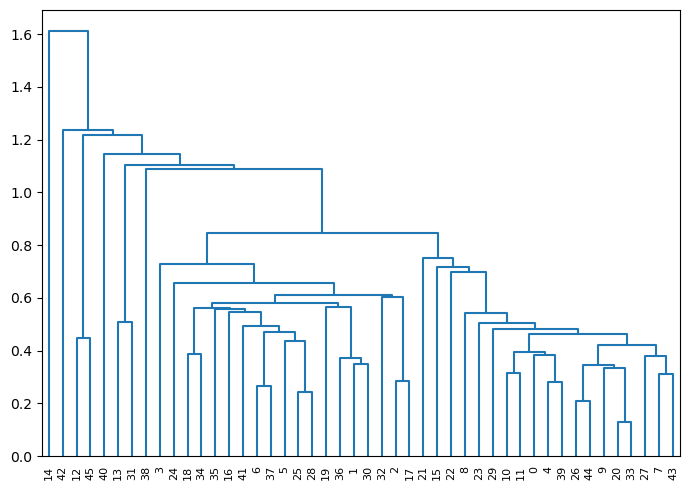

In [56]:
# Рисуем дендрограмму
fig = plt.figure(figsize=(7, 5))

dn = dendrogram(link_single, color_threshold=-1)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Расстояние')

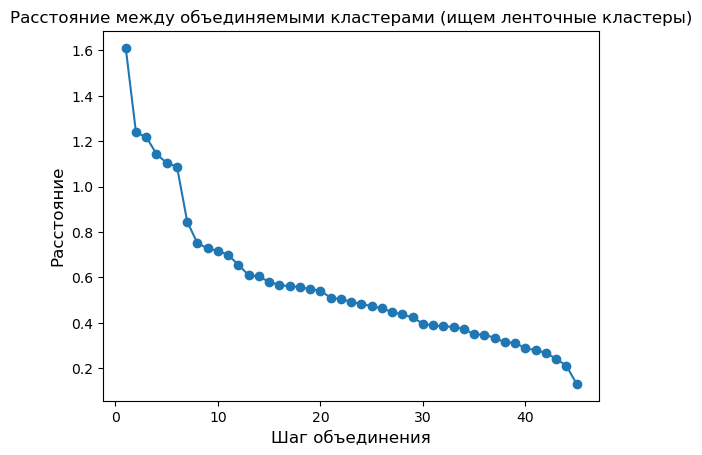

In [97]:
# График каменистая сыпь
dist = link_single[:, 2]
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами (ищем ленточные кластеры)', fontsize=12)
plt.xlabel('Шаг объединения', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)

Исходя из данного графика нужно оставлять много кластеров (примерно 8), попробуем оставить 8 кластеров.

In [59]:
# Оставляем 8 кластеров
df['cluster'] = fcluster(link_single, 8, criterion='maxclust')

#  Средние значения признаков в каждом кластере
# df.groupby('cluster').mean()

In [60]:
# Сколько в каждом кластере объектов
df["cluster"].value_counts()

cluster
4    19
3    19
1     2
2     2
8     1
5     1
6     1
7     1
Name: count, dtype: int64

Видно, что почти все объекты попали в два самых больших кластера, в остальных 6 кластерах не больше 2 объектов.

Попробуем оставить 4 кластера, как мы сделали в иерархическом кластерном анализе.

In [62]:
# Оставляем 4 кластеров
df['cluster'] = fcluster(link_single, 4, criterion='maxclust')

# Сколько в каждом кластере объектов
df["cluster"].value_counts()

cluster
2    42
1     2
4     1
3     1
Name: count, dtype: int64

Почти все объекты попали в один кластер, еще в одном кластере — 2 наблюдения, а в остальных — по одному.

Очевидно, что данные в этой лабораторной имеют явную структуру шаровых кластеров, которая хорошо интерпретируется, а попытки найти ленточные кластеры не дают нормальных и осмысленных результатов.